In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [4]:
olink  <-  read.csv("/vol/projects/yzhang/500FG_aging/input/olink/olink_rank_normalized.csv",row.names=1)
head(olink)
dim(olink)
any(is.na(olink))

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,-1.307515377,-1.8544190,-0.3719828,0.3530425,0.7784212,-0.61267034,-0.6269983,-1.2937415,-0.34048600,-0.08582721,⋯,-1.6850386,-1.1002426,-0.22960821,-0.5088619,2.16145282,-1.1221646,-0.76251161,-0.99775902,-0.85262386,-1.3959291
HV002,0.284609416,-0.9410132,0.8357388,-0.4167151,0.9318480,0.54280488,0.7546289,0.7625116,1.38043474,-1.71000931,⋯,-0.8026625,-0.3656548,-0.04435348,1.5152189,0.02069298,0.1573107,-0.06803884,0.09770089,-0.04435348,-0.4102756
HV003,-0.303127821,0.8526239,-0.3217508,0.3093235,1.2158118,0.09770089,0.9048100,0.4426501,-0.41027562,0.93184798,⋯,0.8273850,-0.2478567,-0.01478019,-1.0476252,-0.11553779,0.4038531,0.16329900,-0.16329900,1.49684359,2.0064213
HV004,-2.397454440,0.2053942,-1.7360943,0.1813000,-2.3039328,-1.04762520,-0.1692932,-1.7921234,-0.91374842,0.87841789,⋯,-0.3404860,-0.4821252,-0.94101316,-0.8784179,-0.79453027,0.3467574,-0.99775902,1.36526489,1.88847460,1.6380316
HV005,0.211435869,0.6055535,2.3039328,0.2600680,2.1614528,0.83573876,-0.2417650,0.6856648,0.47549533,-0.10958835,⋯,0.8026625,1.0476252,-0.25395762,0.8190886,1.15609694,0.2784586,0.72355395,0.52915474,0.85262386,0.1274492
HV006,0.002955934,0.6126703,1.8223874,0.7158943,0.7625116,0.20539420,1.3959291,-0.7467927,0.09770089,0.42317195,⋯,0.6342106,0.7158943,-0.24785670,1.2409543,0.34675740,-0.7158943,-0.93184798,-0.09176243,0.66339834,0.6782053


[1] 424  70

[1] FALSE

In [5]:
basicPhenos = read.csv("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_basicPhenos.csv")
basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ]
dim(basicPhenos)
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(olink), basicPhenos$ID_500fg) 
length(idx) #458samples
olink_filter = olink[which(rownames(olink) %in% idx),]
head(olink_filter)  #458samples,1596 metabolite
dim(olink_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(olink_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(olink_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(olink))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
# save(olink_filter, file = "/vol/projects/yzhang/500FG_aging/output/02_Olink/common_olink_filter_age.RData")
# save(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/output/02_Olink/common_basicPhenos_filter_match_olink_age.RData")

[1] 527  16

[1] 417

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,-1.307515377,-1.8544190,-0.3719828,0.3530425,0.7784212,-0.61267034,-0.6269983,-1.2937415,-0.34048600,-0.08582721,⋯,-1.6850386,-1.1002426,-0.22960821,-0.5088619,2.16145282,-1.1221646,-0.76251161,-0.99775902,-0.85262386,-1.3959291
HV002,0.284609416,-0.9410132,0.8357388,-0.4167151,0.9318480,0.54280488,0.7546289,0.7625116,1.38043474,-1.71000931,⋯,-0.8026625,-0.3656548,-0.04435348,1.5152189,0.02069298,0.1573107,-0.06803884,0.09770089,-0.04435348,-0.4102756
HV003,-0.303127821,0.8526239,-0.3217508,0.3093235,1.2158118,0.09770089,0.9048100,0.4426501,-0.41027562,0.93184798,⋯,0.8273850,-0.2478567,-0.01478019,-1.0476252,-0.11553779,0.4038531,0.16329900,-0.16329900,1.49684359,2.0064213
HV004,-2.397454440,0.2053942,-1.7360943,0.1813000,-2.3039328,-1.04762520,-0.1692932,-1.7921234,-0.91374842,0.87841789,⋯,-0.3404860,-0.4821252,-0.94101316,-0.8784179,-0.79453027,0.3467574,-0.99775902,1.36526489,1.88847460,1.6380316
HV005,0.211435869,0.6055535,2.3039328,0.2600680,2.1614528,0.83573876,-0.2417650,0.6856648,0.47549533,-0.10958835,⋯,0.8026625,1.0476252,-0.25395762,0.8190886,1.15609694,0.2784586,0.72355395,0.52915474,0.85262386,0.1274492
HV006,0.002955934,0.6126703,1.8223874,0.7158943,0.7625116,0.20539420,1.3959291,-0.7467927,0.09770089,0.42317195,⋯,0.6342106,0.7158943,-0.24785670,1.2409543,0.34675740,-0.7158943,-0.93184798,-0.09176243,0.66339834,0.6782053


[1] 417  70

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,HV021,male,22,185,88,25.71220,Single living alone,University student,European,Rarely,No,Yes,16,12,346,2013
2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013
3,HV095,female,24,166,57,20.68515,Married,University degree,European,Once a month,Yes,Yes,16,12,346,2013
4,HV106,male,24,188,81,22.91761,Cohabitation,University degree,European,Never,No,Yes,16,12,346,2013
5,HV107,male,20,172,58,19.60519,Cohabitation,University student,European,Rarely,No,No,16,12,346,2013
6,HV137,female,24,178,72,22.72440,Cohabitation,University student,European,Once a month,Yes,No,16,12,346,2013


...

[1] 0

Warning message in basicPhenos_filter_match$ID_500fg == rownames(olink):
“longer object length is not a multiple of shorter object length”


[1] 187

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
247,HV001,male,27,178,70,22.09317,Married,University degree,European,Once a month,Yes,No,24,7,204,2013
248,HV002,male,26,178,68,21.46194,Cohabitation,University degree,European,Rarely,No,Yes,24,7,204,2013
207,HV003,female,24,173,68,22.72044,Married,University degree,European,Rarely,Yes,Yes,26,8,236,2013
208,HV004,female,20,173,65,21.71807,Married,University degree,European,Rarely,Yes,No,26,8,236,2013
205,HV005,female,22,178,64,20.19947,Married,University student,European,Once a month,Yes,Yes,5,9,245,2013
414,HV006,female,24,168,58,20.54989,Married,University degree,European,Rarely,Yes,No,NA,NA,NA,NA


[1] 417  16

In [6]:
olink_age <- cbind(olink_filter, Age = basicPhenos_filter_match$Age)
head(olink_age)
dim(olink_age)

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV001,-1.307515377,-1.8544190,-0.3719828,0.3530425,0.7784212,-0.61267034,-0.6269983,-1.2937415,-0.34048600,-0.08582721,⋯,-1.1002426,-0.22960821,-0.5088619,2.16145282,-1.1221646,-0.76251161,-0.99775902,-0.85262386,-1.3959291,27
HV002,0.284609416,-0.9410132,0.8357388,-0.4167151,0.9318480,0.54280488,0.7546289,0.7625116,1.38043474,-1.71000931,⋯,-0.3656548,-0.04435348,1.5152189,0.02069298,0.1573107,-0.06803884,0.09770089,-0.04435348,-0.4102756,26
HV003,-0.303127821,0.8526239,-0.3217508,0.3093235,1.2158118,0.09770089,0.9048100,0.4426501,-0.41027562,0.93184798,⋯,-0.2478567,-0.01478019,-1.0476252,-0.11553779,0.4038531,0.16329900,-0.16329900,1.49684359,2.0064213,24
HV004,-2.397454440,0.2053942,-1.7360943,0.1813000,-2.3039328,-1.04762520,-0.1692932,-1.7921234,-0.91374842,0.87841789,⋯,-0.4821252,-0.94101316,-0.8784179,-0.79453027,0.3467574,-0.99775902,1.36526489,1.88847460,1.6380316,20
HV005,0.211435869,0.6055535,2.3039328,0.2600680,2.1614528,0.83573876,-0.2417650,0.6856648,0.47549533,-0.10958835,⋯,1.0476252,-0.25395762,0.8190886,1.15609694,0.2784586,0.72355395,0.52915474,0.85262386,0.1274492,22
HV006,0.002955934,0.6126703,1.8223874,0.7158943,0.7625116,0.20539420,1.3959291,-0.7467927,0.09770089,0.42317195,⋯,0.7158943,-0.24785670,1.2409543,0.34675740,-0.7158943,-0.93184798,-0.09176243,0.66339834,0.6782053,24


[1] 417  71

In [7]:
##perform 100 times
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Set up the grid for hyperparameter tuning
  # netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))    
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
    # Save predicted age for each sample   
   pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training),
      Age_true = training$Age,
      Age_pred = as.numeric(train_predictions),
      stringsAsFactors = FALSE
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation),
      Age_true = validation$Age,
      Age_pred = as.numeric(val_predictions),
      stringsAsFactors = FALSE
    )
  )
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit,
    # selected_features = selected_features,
    predictions = pred_df
  )
}


In [8]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(olink_age, seed = i, iteration = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,7.3486149,0.42955018
2,Validation RMSE,8.7225942,0.69107213
3,Train MSE,54.1848098,6.28175575
4,Validation MSE,76.5564541,12.01249179
5,Train R²,0.6510783,0.03675491
6,Validation R²,0.5029593,0.06396049


In [9]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/olink_prediction_elastic_results.rds")

all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/olink_pre_age_elasticnet_orign_sample_feature.csv", row.names = FALSE)

null device 
          1

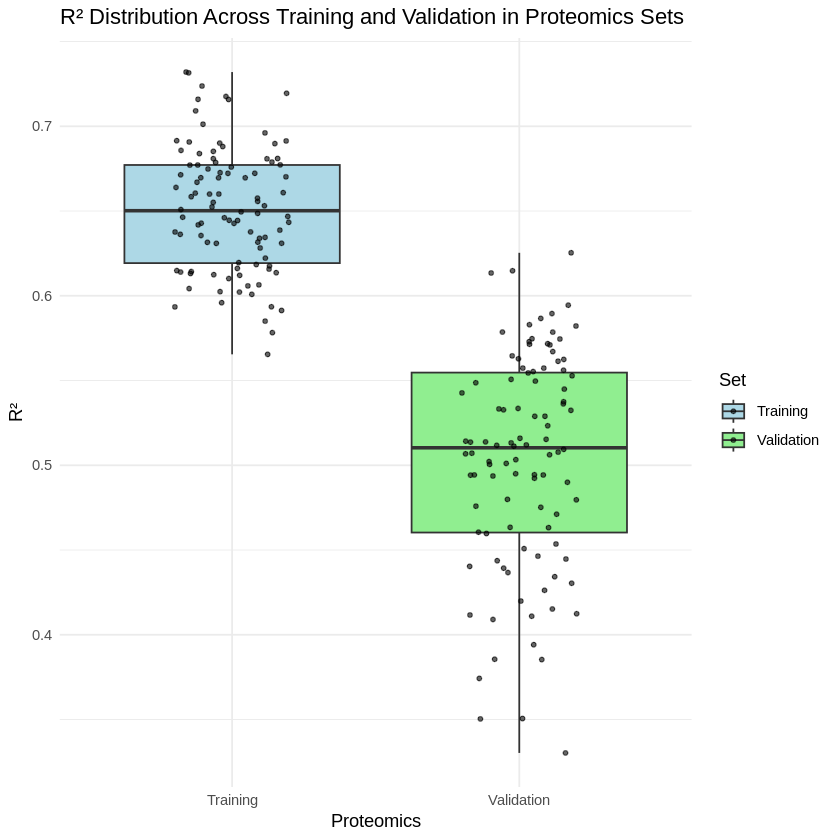

In [10]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
# ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_cross_validation.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Proteomics Sets",
       x = "Proteomics",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [12]:
save.image("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_prediction_elastic_orig_sample_feature.Rdata")